# Academic Failure Prediction Model

## Project Description

### Goal:
- use the given dataset about students and past exams to build a ML model to predict students grades.
- students with predicted scores under 50% will then receive additional support from School Management.


###  Data Pre-processing (10%)
- Missing values / outliers : Robust and nuanced approach
- Categorical encoding : Advanced or balanced encoding strategies
- Scaling numerical features : Method adapted to model needs

### Feature Selection and Creation (5%)
- Relevant feature selection : Justified selection using data or domain logic Optimal features chosen via analysis
- Feature transformation / creation (Optional depending on the necessity) : Useful engineered features Innovative and insightful feature creation.

### Model Comparison and Hyperparameter Selection (25%)
- Dataset splitting : train/val/test split and crossvalidation
- Model training : more than 3 models tested (among which one deep learning model) with choice justification.
- Performance comparison : In-depth multi-metric evaluation
- Hyperparameter selection/tuning : Advanced tuning with crossvalidation
- Over/underfitting analysis : Correct analysis with remedies, Deep, justified understanding

### Presentation of Results (20%)




### Report :
- EDA requires multiple graphs to be complete.
- When evaluating your failure prediction model, use a baseline (for example, the naive average of the students’ grades). This allows you to compare your model with a very simple ”worst-case” model and determine whether your approach performs better.
- For evaluating the OCR system, consider using a confusion matrix.


## Setup & Imports:

We use a kaggle jupyter server.

In [1]:
# from learntools.core import binder
# binder.bind(globals())


# from learntools.machine_learning.ex2 import *
# from learntools.feature_engineering_new.ex2 import *
# from learntools.ml_intermediate.ex1 import *

# Visual
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display


# Machine Learning
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.ensemble import RandomForestRegressor



# Feature Engineering
from sklearn.feature_selection import mutual_info_regression



print("Setup Complete")

Setup Complete


## 1. Introduction / Problem

TODO : write here the introduction

## 2. Data Exploration :

### 2.1 Raw Data Overview

We start by inspecting the raw dataset before making any preprocessing decisions. This is important because it lets us understand the original structure of the data and identify possible issues such as missing values, identifiers, and variable types.

The audit table gives us several useful clues:
- `dtype` tells us how pandas reads each column.
- `missing_values` shows which variables need preprocessing.
- `cardinality` tells us how many different values each column has.
- `mean` is useful for numerical variables.
- `sample_values` helps us see what kind of answers a column contains.

From this first overview, we can already notice that:
- `id` is only an identifier, so it should not be used as a predictive feature.
- Some columns are clearly numerical because they represent measurable quantities.
- Some columns are categorical because they represent labels, choices, or levels.
- A few columns contain missing values, so they will need special treatment later.

This first step helps us build a clear preprocessing strategy instead of encoding or cleaning the data blindly.

In [ ]:
import pandas as pd
from pathlib import Path

# Path of the file to read
dataset_file_path = 'data/project_2026_dataset/student_dataset/student_failure/train.csv'

# # Read the file into a variable
raw_data = pd.read_csv(dataset_file_path) 

# Print
print(raw_data.columns)
# raw_data.describe()


Index(['id', 'age', 'genre', 'diplôme', 'heures_etude', 'assiduité_classe',
       'accès_internet', 'heures_sommeil', 'qualité_sommeil', 'méthode_etude',
       'évaluation_établissement', 'difficulté_examen', 'score_examen',
       'heures_fête', 'taille_etudiant'],
      dtype='str')


In [112]:
# Dataset holding structure
dataset = {}


In [3]:
import pandas as pd
from IPython.display import display

raw_X = raw_data.drop(columns=["score_examen"])

summary = pd.DataFrame({
    "column": raw_X.columns,
    "dtype": [raw_X[col].dtype for col in raw_X.columns],
    "missing_values": [raw_X[col].isna().sum() for col in raw_X.columns],
    "mean": [
        raw_X[col].mean() if pd.api.types.is_numeric_dtype(raw_X[col]) else None
        for col in raw_X.columns
    ],
    "sample_values": [
        raw_X[col].dropna().unique()[:5] for col in raw_X.columns
    ],
    "cardinality": [raw_X[col].nunique() for col in raw_X.columns],

})

display(summary)

,column,dtype,missing_values,mean,sample_values,cardinality
0,id,int64,0,314999.500000,"[0, 1, 2, 3, 4]",630000
1,age,int64,0,20.545821,"[21, 18, 20, 19, 23]",8
2,genre,str,0,NaN,"[male, female]",2
3,diplôme,str,0,NaN,"[Computer Science, Law, Business Management, M...",7
4,heures_etude,float64,18900,4.002779,"[7.91, 4.95, 4.68, 2.0, 7.65]",792
5,assiduité_classe,float64,0,71.987261,"[98.8, 94.8, 92.6, 49.5, 86.9]",617
6,accès_internet,str,63000,NaN,"[yes, no]",2
7,heures_sommeil,float64,0,7.072758,"[4.9, 4.7, 5.8, 8.3, 9.6]",66
8,qualité_sommeil,str,0,NaN,"[average, poor, good]",3
9,méthode_etude,str,44100,NaN,"[online videos, self-study, coaching, group st...",5


The dataset contains a mix of numerical and categorical features. Some numerical variables, such as age, heures_etude, and assiduité_classe, represent real quantities. Other columns are categorical, such as genre, diplôme, qualité_sommeil, and méthode_etude, even if some of them have only a few possible values.

The audit also shows that a few columns contain missing values, especially heures_etude, accès_internet, and méthode_etude. This means preprocessing will need to handle both data type differences and incomplete values before model training.

### 2.2. Variable Typing

Now that we have explored the raw data, we can classify the variables more carefully.


We separate the variables into four groups:

- **Numerical variables**: real quantities that can be measured and compared mathematically.
- **Binary categorical variables**: categories with only two possible values.
- **Ordinal categorical variables**: categories with a natural order.
- **Nominal categorical variables**: categories with no natural order.

This distinction is important because each type of variable needs a different encoding strategy later.


For example:
- `age`, `heures_etude`, `assiduité_classe`, `heures_sommeil`, `heures_fête`, and `taille_etudiant` are numerical because they represent measurable quantities.
- `genre` and `accès_internet` are binary categorical.
- `qualité_sommeil`, `évaluation_établissement`, and `difficulté_examen` are ordinal categorical because their values have a clear order.
- `diplôme` and `méthode_etude` are nominal categorical because they are simply labels without a meaningful ranking.

Even if some numerical columns have only a few unique values, they remain numerical if they represent quantities rather than categories.


#### 2.1 Numerical Variables

The numerical variables are the columns that represent measurable quantities:

- `age`
- `heures_etude`
- `assiduité_classe`
- `heures_sommeil`
- `heures_fête`
- `taille_etudiant`

These columns can be used directly as numbers in the model.  
Even if some of them have only a few unique values, they are still numerical because they represent real quantities and not categories

#### 2.2 Categorical Variables

Categorical variables describe groups, labels, or levels rather than continuous quantities.

In this dataset, we separate them into three groups:
- binary categorical variables
- ordinal categorical variables
- nominal categorical variables

This distinction matters because each group may need a different encoding method later.

##### Binary Categorical

These variables have only two possible values:

- `genre`
- `accès_internet`

Because they only have two categories, they can be encoded very simply, often with one-hot encoding or a 0/1 mapping.

##### Ordinal Categorical

These variables have a natural order:

- `qualité_sommeil` → poor, average, good
- `évaluation_établissement` → low, medium, high
- `difficulté_examen` → easy, moderate, hard

Since the categories are ordered, ordinal encoding can be appropriate here if we want the model to keep that order.

##### Nominal Categorical

These variables do not have a meaningful order:

- `diplôme`
- `méthode_etude`

For these columns, one-hot encoding is usually the safest choice because it does not impose an artificial ranking.


#### 2.3 Final data types

After this inspection, we can summarize the raw predictors as:

- numerical variables: real measurable quantities
- binary categorical variables: two possible labels
- ordinal categorical variables: ordered categories
- nominal categorical variables: unordered categories

This classification will guide the preprocessing step, especially the choice of encoding method.

In [4]:
numerical_cols = [
    "age",
    "heures_etude",
    "assiduité_classe",
    "heures_sommeil",
    "heures_fête",
    "taille_etudiant"
]

binary_categorical_cols = [
    "genre",
    "accès_internet"
]

ordinal_categorical_cols = [
    "qualité_sommeil",
    "évaluation_établissement",
    "difficulté_examen"
]

nominal_categorical_cols = [
    "diplôme",
    "méthode_etude"
]

### 2.3. EDA plots on raw data

#### Plot 1: Distribution of the target :

The distribution of the `exam_score` is roughly bell-shaped and centered around 60.
There is a noticeable spike at `100`, which does not follow the smooth bell curve.

Implications of the spike at score 100
That spike likely means something important:
possible ceiling effect, grade rounding, score clipping, extra bonus / perfect-score group or a subset of students with exceptional performance

- the model may need to learn a pattern that is not fully smooth.
- It also tells us that the prediction task is not just about predicting the center of the distribution; the top end may behave differently.


The target distribution is approximately bell-shaped and centered around 60, but there is a strong spike at 100. This suggests that the score may be capped, rounded, or that a subgroup of students systematically reaches the maximum score. Because of this peak, the target is not perfectly continuous in practice, and the model may need to handle the upper boundary carefully.


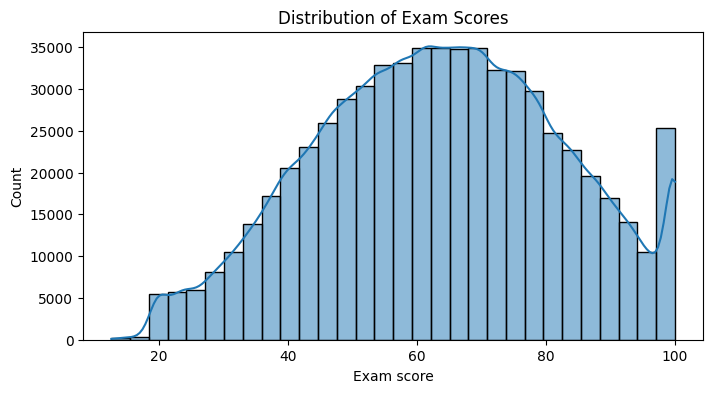

In [5]:
plt.figure(figsize=(8, 4))
sns.histplot(raw_data['score_examen'], bins=30, kde=True)
plt.title("Distribution of Exam Scores")
plt.xlabel("Exam score")
plt.ylabel("Count")
plt.show()

#### Plot 2: Numerical features vs target :

The relationship between study hours and exam score is clearly positive. Students who study more tend to obtain higher scores, and the correlation is strong at about 0.76.

Because the dataset is large and many points overlap, a simple scatterplot becomes too dense. To make the pattern readable, we use a sampled scatterplot together with a binned average trend line. This shows both the local variability and the general upward relationship.

This plot confirms that `heures_etude` is one of the strongest numerical predictors of the target.

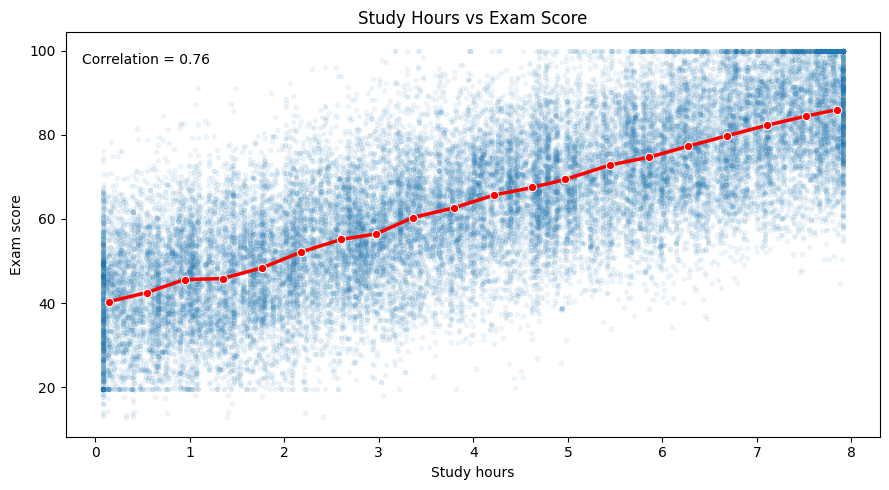

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as snsraw_data

tmp = raw_data[["heures_etude", "score_examen"]].dropna().copy()

# Sample points so the scatter stays readable
sample_df = tmp.sample(n=min(30000, len(tmp)), random_state=0)

# Build bins to show the average trend clearly
tmp["study_bin"] = pd.qcut(tmp["heures_etude"], q=20, duplicates="drop")
bin_summary = tmp.groupby("study_bin", observed=True).agg(
    mean_study_hours=("heures_etude", "mean"),
    mean_score=("score_examen", "mean")
).reset_index()

fig, ax = plt.subplots(figsize=(9, 5))

# faint scatter for local detail
sns.scatterplot(
    data=sample_df,
    x="heures_etude",
    y="score_examen",
    alpha=0.08,
    s=12,
    edgecolor=None,
    ax=ax
)

# trend line using binned averages
sns.lineplot(
    data=bin_summary,
    x="mean_study_hours",
    y="mean_score",
    color="red",
    marker="o",
    linewidth=2.5,
    ax=ax
)

ax.set_title("Study Hours vs Exam Score")
ax.set_xlabel("Study hours")
ax.set_ylabel("Exam score")
ax.text(
    0.02, 0.95,
    f"Correlation = {raw_data[['heures_etude', 'score_examen']].corr().iloc[0,1]:.2f}",
    transform=ax.transAxes,
    va="top"
)

plt.tight_layout()
plt.show()

#### Plot 3: Categorical feature vs target :

This plot shows a clear ordered pattern across study methods. The exam score increases from `self-study` to `coaching`, which suggests that the type of study method is strongly related to performance.

This is interesting because it confirms that `méthode_etude` is not just a nominal category: it behaves like an ordered variable in practice. That means the feature likely contains useful predictive information.

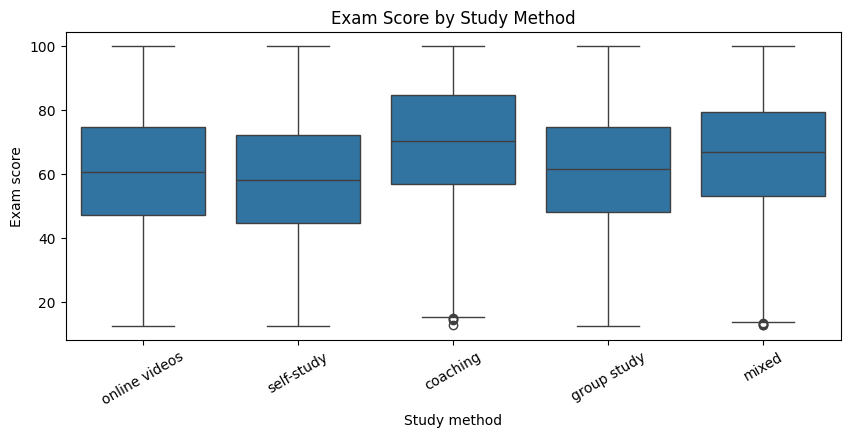

In [7]:
plt.figure(figsize=(10, 4))
sns.boxplot(data=raw_data, x='méthode_etude', y='score_examen')
plt.title("Exam Score by Study Method")
plt.xlabel("Study method")
plt.ylabel("Exam score")
plt.xticks(rotation=30)
plt.show()


#### Plot 3.1: Exam score by internet access

Students with internet access (`yes`) appear to score about 10 points higher on average than students without access (`no`).

This does not prove that internet access alone causes better grades, but it suggests that the feature is associated with performance and may capture access to online learning resources or support.

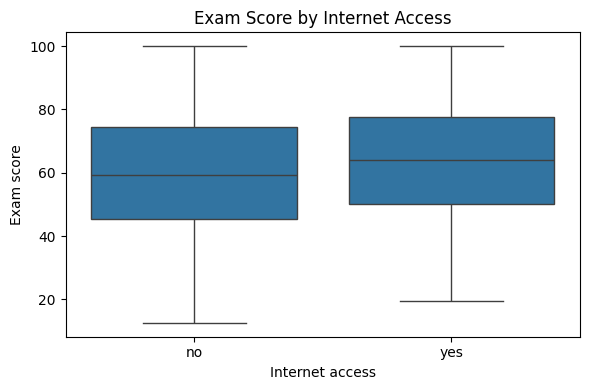

In [8]:
plt.figure(figsize=(6, 4))
sns.boxplot(
    data=raw_data,
    x="accès_internet",
    y="score_examen",
    order=["no", "yes"]
)
plt.title("Exam Score by Internet Access")
plt.xlabel("Internet access")
plt.ylabel("Exam score")
plt.tight_layout()
plt.show()

#### Plot 4: Correlation heatmap for numerical features :

This heatmap summarizes the linear relationships between the numerical variables. Most pairs are very close to zero, which *only* means they are only weakly related linearly.

The strongest relationship is between `heures_etude` and `score_examen` (about 0.76), which makes it the most informative numerical predictor. `assiduité_classe` also has a moderate positive correlation with the target, while `heures_sommeil` has only a weak positive relationship.

Overall, this plot tells us that a few numerical variables are clearly useful, but most of the signal is probably spread across several features rather than concentrated in many strong linear relationships.

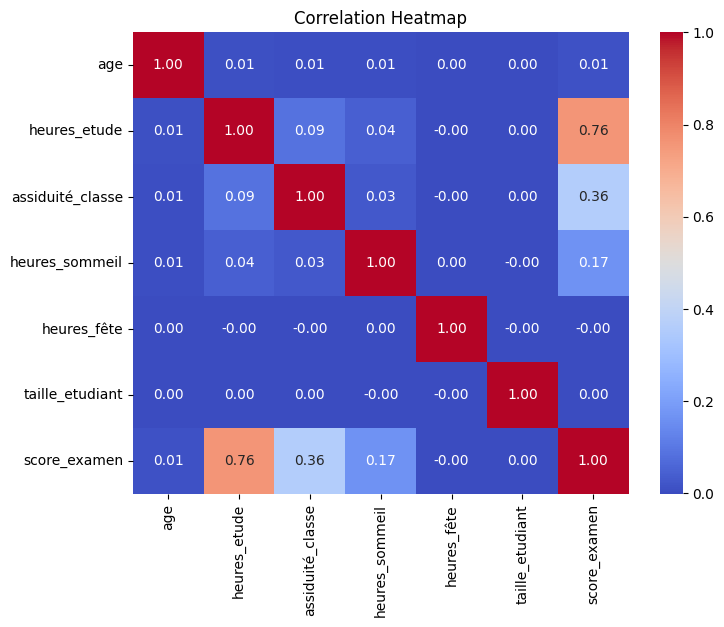

In [9]:
plt.figure(figsize=(8, 6))
sns.heatmap(raw_data[numerical_cols + ['score_examen']].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

the correaltion heatmap shows 0.00 to 0.01 for all the features pairs except for
- score_examen >< heures_étude : 0.76
- score_examen ><assiduité_classe : 0.36
- score_examen >< heures_sommeil : 0.17

#### Notes

Bivariate plots (interaction between features) is done in chapter 4 : Feature Engineering.




## 3. Preprocessing

### 3.1 Dataset Splitting

In [117]:
# 1. Drop target and id columns
X_raw = raw_data.drop(columns=["score_examen", "id"])
y = raw_data["score_examen"]

# Divide data into training and validation subsets
X_train_raw, X_valid_raw, y_train, y_valid = train_test_split(
    X_raw, y, 
    train_size=0.8, 
    test_size=0.2, 
    random_state=0
)

# Dataset holding structure
dataset["raw"] = {
    "X_train": X_train_raw.copy(),
    "X_valid": X_valid_raw.copy(),
    "y_train": y_train.copy(),
    "y_valid": y_valid.copy(),
    "description": "Raw (0.8 - 0.2) split"
}


### 3.2 Missing Values

#### Overview

- the missingness is not tiny
- it is concentrated in only a few columns
- those columns are also meaningful predictors, so dropping them would throw away useful signal


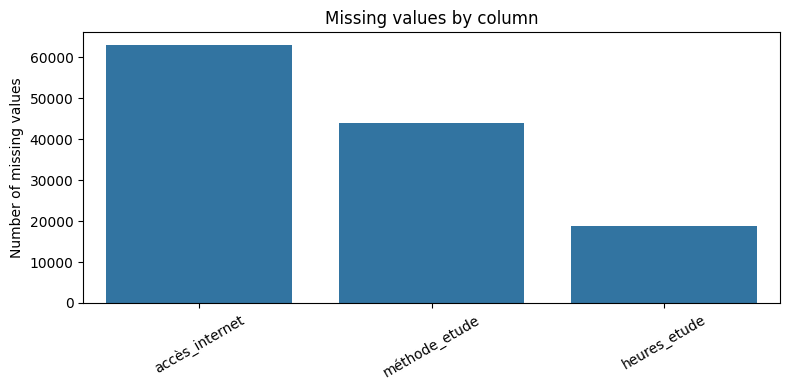

Missing values by column:
accès_internet    63000
méthode_etude     44100
heures_etude      18900
dtype: int64


In [13]:
# Missing-values summary
missing_val_count_by_column = raw_data.isnull().sum()
missing_val_count_by_column = missing_val_count_by_column[missing_val_count_by_column > 0].sort_values(ascending=False)

plt.figure(figsize=(8, 4))
sns.barplot(x=missing_val_count_by_column.index, y=missing_val_count_by_column.values)
plt.title("Missing values by column")
plt.ylabel("Number of missing values")
plt.xlabel("")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


print("Missing values by column:")
print(missing_val_count_by_column)

#### Handling Missing values

Missing values are one of the main preprocessing issues in this dataset.  
Before training the model, we compare three simple strategies:

1. **Drop the columns with missing values**
2. **Impute the missing values**
3. **Impute the missing values and add a missing-value flag**

Because some of the incomplete columns are informative predictors, dropping them would remove useful information from the dataset. For that reason, we expect imputation-based methods to perform better than simple deletion.

To make the comparison fair, we first split the data into training and validation sets, and then we evaluate each approach on the same split.


In [113]:
# We compare three simple strategies:
#   1. Drop columns with missing values
#   2. Impute missing values
#   3. Impute missing values + add missing-value flags
#
#   Since the missing columns are informative, we expect imputation to work better than dropping them.


In [15]:
# ------- General Functions ---------

# Function for comparing different approaches
def score_dataset(X_train, X_valid, y_train, y_valid):
    """From Kaggle - Intermediate Machine Learning : 2 - Missing Values"""
    model = RandomForestRegressor(n_estimators=10, random_state=0)
    model.fit(X_train, y_train)
    preds = model.predict(X_valid)
    return mean_absolute_error(y_valid, preds)


def encode_for_model(train_df, valid_df):
    """One-hot encode train/validation data and align columns."""
    X_train_enc = pd.get_dummies(train_df)
    X_valid_enc = pd.get_dummies(valid_df)
    X_train_enc, X_valid_enc = X_train_enc.align(X_valid_enc, join="left", axis=1, fill_value=0)
    return X_train_enc, X_valid_enc

def impute_dataframe(train_df, valid_df):
    """Median for numeric columns, most-frequent for categorical columns.
        -> this is a custom function similar to SimpleImputer.
    """
    train_df = train_df.copy()
    valid_df = valid_df.copy()

    numeric_cols = train_df.select_dtypes(include="number").columns
    categorical_cols = train_df.select_dtypes(exclude="number").columns

    for col in numeric_cols:
        fill_value = train_df[col].median()
        train_df[col] = train_df[col].fillna(fill_value)
        valid_df[col] = valid_df[col].fillna(fill_value)

    for col in categorical_cols:
        fill_value = train_df[col].mode(dropna=True)[0]
        train_df[col] = train_df[col].fillna(fill_value)
        valid_df[col] = valid_df[col].fillna(fill_value)

    return train_df, valid_df



#### Approach 1: Drop columns with missing values

This is the simplest solution, but it removes all information from the affected columns. In our case, that is not ideal because the missing columns are not useless variables; they still contain predictive signal.


In [16]:
# Get names of columns with missing values
cols_with_missing = [col for col in X_train_raw.columns
                    if X_train_raw[col].isnull().any()]

# Drop columns in training and validation data
drop_X_train = X_train_raw.drop(columns=cols_with_missing)
drop_X_valid = X_valid_raw.drop(columns=cols_with_missing)

drop_X_train_enc, drop_X_valid_enc = encode_for_model(drop_X_train, drop_X_valid)

mae_drop = score_dataset(drop_X_train_enc, drop_X_valid_enc, y_train, y_valid)
print("MAE from Approach 1 (Drop columns with missing values):")
print(mae_drop)



MAE from Approach 1 (Drop columns with missing values):
14.375106051097882


#### Approach 2: Imputation

Here, we fill missing values instead of deleting the columns.  
For numerical variables, we use the **median**, because it is robust to extreme values.  
For categorical variables, we use the **most frequent value** so that the missing entries are replaced with a realistic category.

We see that Approach 2 has lower MAE than Approach 1, so Approach 2 performed better on this dataset.

In [17]:
# Imputation
imp_X_train, imp_X_valid = impute_dataframe(X_train_raw, X_valid_raw)
imp_X_train_enc, imp_X_valid_enc = encode_for_model(imp_X_train, imp_X_valid)

mae_imp = score_dataset(imp_X_train_enc, imp_X_valid_enc, y_train, y_valid)
print("MAE from Approach 2 (Imputation):")
print(mae_imp)



MAE from Approach 2 (Imputation):
7.901258163492063


#### Approach 3: Imputation + missing-value flag

This method goes one step further. In addition to filling missing values, we create a binary indicator that shows whether each value was originally missing or not. This can be useful when the pattern of missingness itself contains information.

In our results, **Approach 3 achieves the best MAE: 7.83**.  
This suggests that the missingness pattern is slightly informative, and that keeping this information helps the model perform better. Therefore, for the rest of the report, we will use **Approach 3** as our final preprocessing choice.


In [18]:
# Next, we impute the missing values, while also keeping track of which values were imputed.

# Make copy to avoid changing original data (when imputing)
X_train_plus = X_train_raw.copy()
X_valid_plus = X_valid_raw.copy()

# Make new columns indicating what will be imputed
for col in cols_with_missing:
    X_train_plus[col + '_was_missing'] = X_train_plus[col].isna().astype(int)
    X_valid_plus[col + '_was_missing'] = X_valid_plus[col].isna().astype(int)

# Imputation
imputed_X_train_plus, imputed_X_valid_plus = impute_dataframe(X_train_plus, X_valid_plus)
flag_X_train_enc, flag_X_valid_enc = encode_for_model(imputed_X_train_plus, imputed_X_valid_plus)


mae_flag = score_dataset(flag_X_train_enc, flag_X_valid_enc, y_train, y_valid)
print("MAE from Approach 3 (Imputation + flag):")
print(mae_flag)

# print("Number of missing columns:", len(cols_with_missing))
# print("Missing columns:", cols_with_missing)

MAE from Approach 3 (Imputation + flag):
7.834090297619047


#### So, why did imputation perform better than dropping the columns?

The training data has 504000 rows and 32 columns, where 1 column contain missing data. 

The training data has many rows and 32 columns, and only one column contains missing values. Since relatively few values are missing, dropping the entire column removes useful information from the dataset. Imputation, on the other hand, preserves that information by filling in the missing entries, which is why it performs better here.

In [19]:
# Shape of training data (num_rows, num_columns)
print(X_train_raw.shape)

# Number of missing values in each column of training data
missing_val_count_by_column = (X_train_raw.isnull().sum())
print(missing_val_count_by_column[missing_val_count_by_column > 0])

(504000, 13)
heures_etude      15065
accès_internet    50346
méthode_etude     35432
dtype: int64


#### Final choice for the next steps


For this dataset, imputation + missing-value flags is a stronger choice than dropping the column. It keeps more information available to the model while still handling the missing values in a reasonable way.

In [134]:
# our choice of imputed values that will be used for the next steps
approach3_X_train = imputed_X_train_plus.copy()
approach3_X_valid = imputed_X_valid_plus.copy()


dataset["imputed_with_flag"] = {
    "X_train": approach3_X_train.copy(),
    "X_valid": approach3_X_valid.copy(),
    "description": "Imputed split with missingness flags"
}




### 3.3 Extreme Values/Outliers

Extreme values are observations far from the rest of the data.
They are often called outliers, but not every extreme value is a problem.
Some are errors (impossible values, bad data entry).
Some are real but rare values, which may still be useful.




The boxplots help us check whether some numerical variables contain extreme values. In this dataset, the numerical features appear to stay within plausible ranges, so we do not remove outliers aggressively. Since the tree-based models used later are fairly robust, we prefer to keep the data unchanged unless a value is clearly suspicious.

Later we might use Outliers handling techniques such as : 
- keep all values
- cap outliers
- remove outliers
- transform skewed columns

And compare them with each other.

Note : see boxplot documentation [here](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.boxplot.html)

```bash
     Q1-1.5IQR   Q1   median  Q3   Q3+1.5IQR
                  |-----:-----|
  o      |--------|     :     |--------|    o  o
                  |-----:-----|
flier             <----------->            fliers
                       IQR
```



,feature,min,max,median,q1,q3,iqr
0,age,17.00,24.00,21.00,19.00,23.00,4.00
1,heures_etude,0.08,7.91,4.00,2.03,6.00,3.97
2,assiduité_classe,40.60,99.40,72.50,57.00,87.20,30.20
3,heures_sommeil,4.10,9.90,7.10,5.60,8.60,3.00
4,heures_fête,0.00,19.00,4.00,3.00,5.00,2.00
5,taille_etudiant,1.48,2.03,1.75,1.66,1.85,0.19


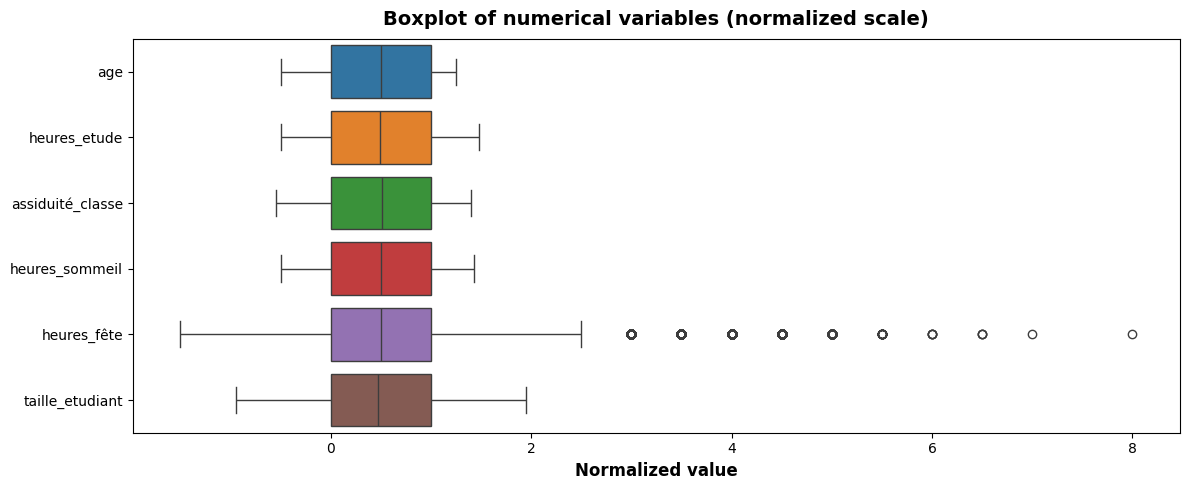

In [124]:
# small outlier check for numerical variables
# Print dynamic scale info for each numerical feature

scale_summary = pd.DataFrame({
    "feature": numerical_cols,
    "min": [approach3_X_train[col].min() for col in numerical_cols],
    "max": [approach3_X_train[col].max() for col in numerical_cols],
    "median": [approach3_X_train[col].median() for col in numerical_cols],
    "q1": [approach3_X_train[col].quantile(0.25) for col in numerical_cols],
    "q3": [approach3_X_train[col].quantile(0.75) for col in numerical_cols],
})

scale_summary["iqr"] = scale_summary["q3"] - scale_summary["q1"]
display(scale_summary)

# Robust normalization per feature for visualization
normalized_outlier_df = approach3_X_train[numerical_cols].copy()

for col in numerical_cols:
    q1 = normalized_outlier_df[col].quantile(0.25)
    q3 = normalized_outlier_df[col].quantile(0.75)
    iqr = q3 - q1

    if iqr == 0:
        normalized_outlier_df[col] = 0
    else:
        normalized_outlier_df[col] = (normalized_outlier_df[col] - q1) / iqr

plt.figure(figsize=(12, 5))
sns.boxplot(data=normalized_outlier_df, orient="h")
plt.title("Boxplot of numerical variables (normalized scale)")
plt.xlabel("Normalized value")
plt.tight_layout()
plt.show()

In [125]:
# Boxplot fences and outlier counts for each numerical column
outlier_report = []

for col in numerical_cols:
    q1 = approach3_X_train[col].quantile(0.25)
    q3 = approach3_X_train[col].quantile(0.75)
    iqr = q3 - q1
    lower_fence = q1 - 1.5 * iqr
    upper_fence = q3 + 1.5 * iqr

    n_outliers = ((approach3_X_train[col] < lower_fence) | (approach3_X_train[col] > upper_fence)).sum()

    outlier_report.append({
        "feature": col,
        "q1": q1,
        "q3": q3,
        "iqr": iqr,
        "lower_fence": lower_fence,
        "upper_fence": upper_fence,
        "n_outliers": n_outliers,
        "min": approach3_X_train[col].min(),
        "max": approach3_X_train[col].max(),
    })

outlier_report_df = pd.DataFrame(outlier_report)
display(outlier_report_df)



col = "heures_fête"

q1 = approach3_X_train[col].quantile(0.25)
q3 = approach3_X_train[col].quantile(0.75)
iqr = q3 - q1
lower_fence = q1 - 1.5 * iqr
upper_fence = q3 + 1.5 * iqr

outliers = approach3_X_train.loc[
    (approach3_X_train[col] < lower_fence) | (approach3_X_train[col] > upper_fence),
    col
].sort_values()

print("Lower fence:", lower_fence)
print("Upper fence:", upper_fence)
print("Outlier values:")
print(outliers.value_counts().sort_index())

,feature,q1,q3,iqr,lower_fence,upper_fence,n_outliers,min,max
0,age,19.00,23.00,4.00,13.000,29.000,0,17.00,24.00
1,heures_etude,2.03,6.00,3.97,-3.925,11.955,0,0.08,7.91
2,assiduité_classe,57.00,87.20,30.20,11.700,132.500,0,40.60,99.40
3,heures_sommeil,5.60,8.60,3.00,1.100,13.100,0,4.10,9.90
4,heures_fête,3.00,5.00,2.00,0.000,8.000,10807,0.00,19.00
5,taille_etudiant,1.66,1.85,0.19,1.375,2.135,0,1.48,2.03


Lower fence: 0.0
Upper fence: 8.0
Outlier values:
heures_fête
9     6629
10    2739
11     970
12     335
13     108
14      17
15       4
16       3
17       1
19       1
Name: count, dtype: int64


“heures_fête shows a mild-to-strong right skew, with a large concentration around 3–5 hours and a long upper tail. According to the IQR rule, values above 8 are statistical outliers, but they remain plausible observations rather than obvious errors. For this reason, we keep the feature and avoid aggressive removal.”

Note : these outliers could be strong predictors of academic success.

### 3.4 Categorical encoding : 

After the raw audit, variable typing, EDA, and missing-value analysis, we now have a clearer view of the categorical variables in the dataset.

The EDA suggested that not all categorical variables should be treated the same way:
- `méthode_etude` behaves like an ordered variable in practice,
- `accès_internet` separates students into two meaningful groups,
- `genre` is a binary label,
- `diplôme` does not have a natural ranking.

We also already handled missing values in the previous step. For Approach 3, missingness is kept as additional binary flag columns, which means that the information about “was missing or not” is preserved explicitly in the dataset.

The goal of this section is therefore to choose an encoding strategy that matches the meaning of each categorical variable, instead of applying the same method everywhere.


1. Ordinal Encoding :
Ordinal encoding assigns each unique value to a different integer. But this assumes an ordering of the categories which doesn't always fit certain situations by giving more weight to certain variables when it doesn't always make sense.



2. One-Hot Encoding
One-hot encoding creates new columns indicating the presence (or absence) of each possible value in the original data
one-hot encoding does not assume an ordering of the categories. Thus, you can expect this approach to work particularly well if there is no clear ordering in the categorical data (e.g., "Red" is neither more nor less than "Yellow"). We refer to categorical variables without an intrinsic ranking as nominal variables.

#### Encoding choice by group 

- **Binary categorical**(`genre`, `accès_internet`): use `0/1` mapping or one-hot encoding; both are fine, but 0/1 is simpler.
- **Ordinal categorical** (`qualité_sommeil`, `évaluation_établissement`, `difficulté_examen`): use ordinal encoding, because their order carries meaning.
- **Nominal categorical** (`diplôme`, `méthode_etude`): use one-hot encoding, because there is no natural ranking.

#### How we compare Encodings

1. Build Baseline: “simple sklearn preprocessing with one-hot for all categorical variables”
2. Final best pipeline: “more structured encoding using binary / ordinal / nominal treatment”
3. Compare
4. Then try small variants where you change one encoding choice at a time.

Note : we use the same Pipeline structure as given in Kaggle "Intermediate ML - 4 Pipelines".

#### Single Encoded pipeline

In [171]:
# 1. Baseline model : (inspired from Kaggle: 4 - Pipelines)
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

# Baseline preprocessing
numerical_transformer = SimpleImputer(strategy="median")

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

single_encoded_preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_transformer  , numerical_cols),
        ("bin", categorical_transformer, binary_categorical_cols),
        ("ord", categorical_transformer, ordinal_categorical_cols),
        ("nom", categorical_transformer, nominal_categorical_cols),
    ]
)


# --------- Store into dataset ---------
X_train = approach3_X_train
X_valid = approach3_X_valid

single_encoded_preprocessor_data = clone(single_encoded_preprocessor)
single_encoded_preprocessor_data.fit(X_train)

single_encoded_X_train = single_encoded_preprocessor_data.transform(X_train)
single_encoded_X_valid = single_encoded_preprocessor_data.transform(X_valid)

dataset["single_encoded"] = {
    "X_train": single_encoded_X_train,
    "X_valid": single_encoded_X_valid,
    "preprocessor": single_encoded_preprocessor_data,
    "description": "One-hot encoded features"
}


# ------- Fit into a test model ----------
test_single_encoded_model = RandomForestRegressor(n_estimators=3, random_state=0)

# Use from previous dataset
X_train = dataset["single_encoded"]["X_train"]
X_valid = dataset["single_encoded"]["X_valid"]

test_single_encoded_model.fit(X_train, y_train)

baseline_preds = test_single_encoded_model.predict(X_valid)  # 8.717805534391534


test_baseline_mae = mean_absolute_error(y_valid, baseline_preds)

print("Test single-encoded MAE:", test_baseline_mae)

Test single-encoded MAE: 8.717805534391534


#### Multi encoded pipeline

In [ ]:
# 2. Final Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

# Numerical features
numerical_transformer = SimpleImputer(strategy="median")   # numeric columns will have missing values filled with the median.

# Binary features
binary_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),  # Missing binary values are imputed with the most frequent value.
    ("ordinal", OrdinalEncoder())                          #  turns the binary categories into numbers like 0 and 1.
])

# Ordinal features
ordinal_categories = [
    ["poor", "average", "good"],
    ["low", "medium", "high"],
    ["easy", "moderate", "hard"]
]
ordinal_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),       # Missing ordinal values are imputed.
    ("ordinal", OrdinalEncoder(categories=ordinal_categories))  # converts ordered categories into ordered integers.
])

# Nominal features
nominal_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),    # Missing nominal values are imputed.
    ("onehot", OneHotEncoder(handle_unknown="ignore"))       # expands categories into dummy columns.
])

multi_encoded_preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_transformer, numerical_cols),
        ("bin", binary_transformer   , binary_categorical_cols),
        ("ord", ordinal_transformer  , ordinal_categorical_cols),
        ("nom", nominal_transformer  , nominal_categorical_cols),
    ]
)

# --------- Store into dataset ---------
X_train = approach3_X_train
X_valid = approach3_X_valid

multi_encoded_preprocessor_data = clone(multi_encoded_preprocessor)
multi_encoded_preprocessor_data.fit(X_train)

single_encoded_X_train = multi_encoded_preprocessor_data.transform(X_train)
single_encoded_X_valid = multi_encoded_preprocessor_data.transform(approach3_X_valid)

dataset["single_encoded"] = {
    "X_train": single_encoded_X_train,
    "X_valid": single_encoded_X_valid,
    "preprocessor": multi_encoded_preprocessor_data,
    "description": "One-hot encoded features"
}


# ------- Fit into a test model ----------
test_multi_encoded_model = RandomForestRegressor(n_estimators=3, random_state=0)

# Use from previous dataset
X_train = dataset["single_encoded"]["X_train"]
X_valid = dataset["single_encoded"]["X_valid"]

test_multi_encoded_model.fit(X_train, y_train)

multi_encoded_preds = test_multi_encoded_model.predict(X_valid)  # 8.717805534391534


test_multi_encoded_mae = mean_absolute_error(y_valid, multi_encoded_preds)

print("Test Multi-encoded MAE:", test_multi_encoded_mae)



Test Multi-encoded MAE: 8.709697261904761


Using n_estimators = 100

- Baseline MAE: 7.552525982698413
- Final MAE: 7.555332094444444


#### Insights

The baseline and the final structured pipeline obtain nearly the same MAE, with the baseline being only marginally better on this validation split. The difference is too small to be considered meaningful and is likely due to normal split variability rather than a real improvement. This suggests that, for this dataset and model, the categorical encoding strategy has only a limited effect on performance. Since the structured pipeline is more consistent with the meaning of the variables and easier to justify in the report, it is reasonable to keep it for the final analysis, but this choice should be confirmed with cross-validation before drawing a final conclusion.

### 3.5 Scaling numerical features :

Scaling is a way to put numerical features on a comparable range.

A.k.a standardizing all the numerical features into a unique scale (eg. 0 - 1.0).


This is not strictly necessary for tree-based models (`DecisionTreeRegressor`, `RandomForestRegressor`, `XGBoost`)


Models that usually need scaling

- Linear models: LinearRegression, Ridge, Lasso, ElasticNet
- Distance-based models: KNN, SVM, k-means
- Neural nets: MLPRegressor, deep learning models
- Gradient-based optimization models: anything trained by gradient descent usually benefits from scaling


TODO : previous baseline is a tree, is it interesting to add a linear baseline (which would then need scaling ?)


In [184]:
# if we later need it
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler

# Change only from the previous numerical preprocessing
scaled_numerical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler" , RobustScaler())
])

# reuse same mutli_encoded strategies, except Numerical
scaled_preprocessor = ColumnTransformer(
    transformers=[
        ("num", scaled_numerical_transformer, numerical_cols),
        ("bin", binary_transformer          , binary_categorical_cols),
        ("ord", ordinal_transformer         , ordinal_categorical_cols),
        ("nom", nominal_transformer         , nominal_categorical_cols),
    ]
)



# --------- Store into dataset ---------
X_train = approach3_X_train
X_valid = approach3_X_valid

scaled_preprocessor_data = clone(scaled_preprocessor)
scaled_preprocessor_data.fit(X_train)

scaled_X_train = scaled_preprocessor_data.transform(X_train)
scaled_X_valid = scaled_preprocessor_data.transform(X_valid)

dataset["scaled"] = {
    "X_train": scaled_X_train,
    "X_valid": scaled_X_valid,
    "preprocessor": scaled_preprocessor_data,
    "description": "Multi encoding + scaling"
}


# ------- Fit into a test model ----------
test_scaled_model = RandomForestRegressor(n_estimators=3, random_state=0)

# Use from previous dataset
X_train = dataset["scaled"]["X_train"]
X_valid = dataset["scaled"]["X_valid"]

test_scaled_model.fit(X_train, y_train)

scaled_preds = test_scaled_model.predict(X_valid)  # 8.717805534391534


test_scaled_mae = mean_absolute_error(y_valid, scaled_preds)

print("Test scaled MAE:", test_scaled_mae)



Test scaled MAE: 8.712698531746033


## 4. Feature Engineering

Feature engineering helps us create more informative inputs from the raw variables.
In this dataset, the goal is not to add many complex transformations, but to test a few simple and meaningful features that may capture student behavior better than the raw columns alone.

We first use mutual information to check which variables appear most informative.
Then we try a small number of domain-inspired features based on study time, attendance, sleep, and leisure time.
Finally, we compare the model performance before and after feature engineering to keep only what truly helps.

Goal : creating or transforming features so the model can learn better patterns.


ex. combine `heures_etude` and `heures_fête` into a `study_life` balance feature.



### 4.1. Mutual Information

mutual information is that it can detect any kind of relationship (e.g. non-linear), while correlation only detects linear relationships.


- Very good for ranking numeric features and encoded categorical features.
- which raw features are worth keeping,
- whether some variables are weak and maybe unnecessary,
- whether the engineered features actually matter.




In [82]:
# Kaggle Utility functions from Tutorial

from sklearn.feature_selection import mutual_info_regression
import pandas as pd

def make_mi_scores(X, y):
    X = X.copy()
    for colname in X.select_dtypes(["object", "category"]):
        X[colname], _ = X[colname].factorize()
    # All discrete features should now have integer dtypes
    discrete_features = [pd.api.types.is_integer_dtype(t) for t in X.dtypes]
    mi_scores = mutual_info_regression(X, y, discrete_features=discrete_features, random_state=0)
    mi_scores = pd.Series(mi_scores, name="MI Scores", index=X.columns)
    mi_scores = mi_scores.sort_values(ascending=False)
    return mi_scores


def plot_mi_scores(scores):
    scores = scores.sort_values(ascending=True)
    width = np.arange(len(scores))
    ticks = list(scores.index)
    plt.barh(width, scores)
    plt.yticks(width, ticks)
    plt.title("Mutual Information Scores")

/tmp/ipykernel_7800/2464721298.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for colname in X.select_dtypes(["object", "category"]):


heures_etude                  0.628489
genre                         0.385986
assiduité_classe              0.174912
diplôme                       0.044910
heures_sommeil                0.043740
accès_internet                0.043601
qualité_sommeil               0.032636
méthode_etude                 0.030105
évaluation_établissement      0.024719
age                           0.007982
difficulté_examen             0.003933
taille_etudiant               0.000842
méthode_etude_was_missing     0.000531
accès_internet_was_missing    0.000391
heures_etude_was_missing      0.000167
heures_fête                   0.000000
Name: MI Scores, dtype: float64

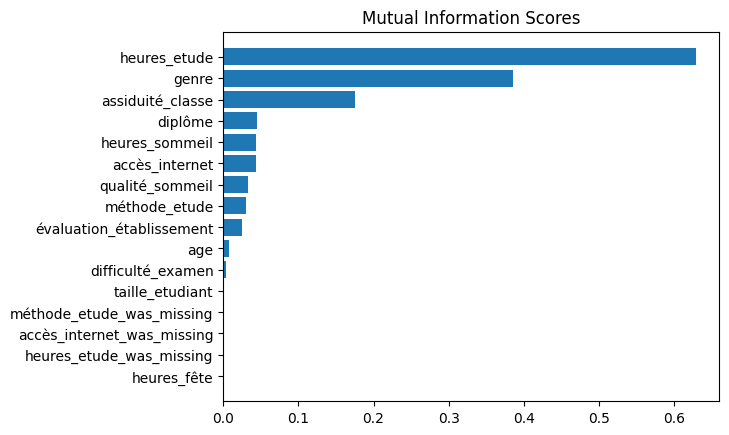

In [85]:
# Compute mutual information scores

X_mi = approach3_X_train.copy()           # use imputed dataset (not multi-encoded)
mi_scores = make_mi_scores(X_mi, y_train)

display(mi_scores)
plot_mi_scores(mi_scores)

Main Insights :
- heures_etude dominates: it is by far the most informative feature, so study time is the clearest predictor of exam score.
- genre is surprisingly strong: that suggests the target differs noticeably by gender in this dataset, so it’s worth checking for bias or hidden group effects.
- assiduité_classe matters, but less: attendance has signal, but much weaker than study time.
- Sleep and internet access are weak but non-zero: they likely help a little, but they are not primary drivers.
- heures_fête has MI = 0: by itself, it does not explain the target well, though it might still matter through interactions like study_balance or busy_score.


#### Bias Check for `genre` feature

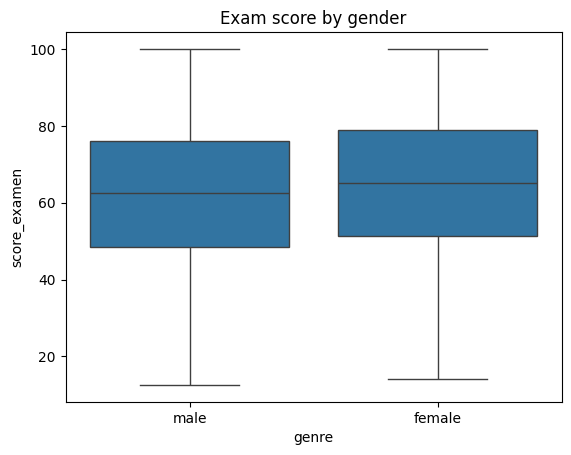

genre
female    8.727064
male      8.711100
Name: abs_error, dtype: float64

In [86]:
# Bias check for genre
sns.boxplot(data=raw_data, x="genre", y="score_examen")
plt.title("Exam score by gender")
plt.show()

val_results = pd.DataFrame({
    "genre": X_valid_raw["genre"].values,
    "y_true": y_valid.values,
    "y_pred": baseline_preds
})
val_results["abs_error"] = (val_results["y_true"] - val_results["y_pred"]).abs()
val_results.groupby("genre")["abs_error"].mean()

model appears to perform almost identically for both groups, so there is no obvious gender-based prediction bias in terms of average absolute error.

### Interactions between features

In [ ]:
# Interaction scan: test all numeric x categorical pairs
# This helps us see which combinations are worth exploring later.

import numpy as np
import pandas as pd
from IPython.display import display

categorical_cols = binary_categorical_cols + ordinal_categorical_cols + nominal_categorical_cols
numeric_cols = numerical_cols

def slope_of_group(df, x_col, y_col="score_examen"):
    if len(df) < 2 or df[x_col].nunique() < 2:
        return np.nan
    return np.polyfit(df[x_col], df[y_col], 1)[0]

candidate_rows = []

for cat_col in categorical_cols:
    for num_col in numeric_cols:
        tmp = raw_data[["score_examen", cat_col, num_col]].dropna().copy()

        # skip useless cases
        if tmp[cat_col].nunique() < 2 or tmp[num_col].nunique() < 2:
            continue

        group_rows = []
        for category, group in tmp.groupby(cat_col):
            group_rows.append({
                "category": category,
                "count": len(group),
                "mean_score": group["score_examen"].mean(),
                "slope": slope_of_group(group, num_col),
            })

        group_df = pd.DataFrame(group_rows)

        candidate_rows.append({
            "numeric_feature": num_col,
            "categorical_feature": cat_col,
            "mean_score_range": group_df["mean_score"].max() - group_df["mean_score"].min(),
            "slope_range": group_df["slope"].max() - group_df["slope"].min(),
            "avg_group_size": group_df["count"].mean(),
        })

interaction_scan = pd.DataFrame(candidate_rows)

print("=== Interaction scan ranking ===")
display(interaction_scan.sort_values(["mean_score_range", "slope_range"],ascending=False))

best_candidate = interaction_scan.sort_values(["mean_score_range", "slope_range"],ascending=False).iloc[0]

# print(
#     f"\nBest pair: `{best_candidate['numeric_feature']}` + `{best_candidate['categorical_feature']}`"
# )

=== Interaction scan ranking ===


,numeric_feature,categorical_feature,mean_score_range,slope_range,avg_group_size
37,heures_etude,méthode_etude,11.565024,0.154669,113666.6
41,taille_etudiant,méthode_etude,11.555361,0.309225,117180.0
39,heures_sommeil,méthode_etude,11.555361,0.204353,117180.0
40,heures_fête,méthode_etude,11.555361,0.046790,117180.0
36,age,méthode_etude,11.555361,0.041831,117180.0
38,assiduité_classe,méthode_etude,11.555361,0.030761,117180.0
17,taille_etudiant,qualité_sommeil,10.866109,0.896808,210000.0
15,heures_sommeil,qualité_sommeil,10.866109,0.259392,210000.0
12,age,qualité_sommeil,10.866109,0.092567,210000.0
16,heures_fête,qualité_sommeil,10.866109,0.032102,210000.0


### Insights :

`mean_score_range`:
- is basically telling you which categorical feature separates students the most overall.
- solely based on the categorical feature (how much does the avg exam score vary between the categories ?)


`slope_range` is telling you which numeric feature changes its effect the most across that categorical feature.


méthode_etude :
- It has the highest mean_score_range values (11.56). That means students in different study-method groups have clearly different average scores.

The correlation heatmap in EDA plots shows that heures_etude, assiduité_classe, and heures_sommeil are the strongest direct numeric predictors of score_examen. But MI score is better at capturing non-linear relationships between features, it is the better guide to identify our engineered features.


Features to try out :
1. heures_etude × méthode_etude
2. heures_sommeil × qualité_sommeil
3. heures_etude × évaluation_établissement
4. heures_etude × accès_internet



### 4.2. Feature Creation

In [132]:
from sklearn.model_selection import train_test_split
import pandas as pd

# 1) Start from the imputed + missing-flag dataset
X_train = dataset["imputed_with_flag"]["X_train"]
X_valid = dataset["imputed_with_flag"]["X_valid"]


# 2) Helper: add numeric x categorical interactions
def add_numeric_categorical_interactions(train_df, valid_df, numeric_col, categorical_col, drop_original_cat=False):
    train_df = train_df.copy()
    valid_df = valid_df.copy()

    train_dummies = pd.get_dummies(train_df[categorical_col], prefix=categorical_col)
    valid_dummies = pd.get_dummies(valid_df[categorical_col], prefix=categorical_col)

    train_dummies, valid_dummies = train_dummies.align(valid_dummies, join="left", axis=1, fill_value=0)

    for dummy_col in train_dummies.columns:
        interaction_name = f"{numeric_col}__x__{dummy_col}"
        train_df[interaction_name] = train_df[numeric_col] * train_dummies[dummy_col]
        valid_df[interaction_name] = valid_df[numeric_col] * valid_dummies[dummy_col]

    if drop_original_cat:
        train_df = train_df.drop(columns=[categorical_col])
        valid_df = valid_df.drop(columns=[categorical_col])

    return train_df, valid_df



# Baseline = dataset["imputed_with_flag"]["X_train"]

# 1. heures_etude × méthode_etude
data = add_numeric_categorical_interactions(X_train, X_valid, "heures_etude", "méthode_etude")
dataset["study_quality"] = {
    "X_train": data[0],
    "X_valid": data[1],
    "description": "heures_etude × méthode_etude",
}

# 2. heures_sommeil × qualité_sommeil
data = add_numeric_categorical_interactions(X_train, X_valid, "heures_sommeil", "qualité_sommeil")
dataset["sleep_quality"] = {
    "X_train": data[0],
    "X_valid": data[1],
    "description": "heures_sommeil × qualité_sommeil",
}

# 3. heures_etude × évaluation_établissement
data = add_numeric_categorical_interactions(X_train, X_valid, "heures_etude", "évaluation_établissement")
dataset["study_school"] = {
    "X_train": data[0],
    "X_valid": data[1],
    "description": "heures_etude × évaluation_établissement",
}

# 4. heures_etude × accès_internet
data = add_numeric_categorical_interactions(X_train, X_valid, "heures_etude", "accès_internet")
dataset["study_internet"] = {
    "X_train": data[0],
    "X_valid": data[1],
    "description": "heures_etude × accès_internet",
}

# 4) Quick check
for name, variant in dataset.items():
    if isinstance(variant, dict) and "X_train" in variant and "X_valid" in variant:
        print(name, variant["X_train"].shape, variant["X_valid"].shape)

raw (504000, 13) (126000, 13)
imputed_with_flag (504000, 16) (126000, 16)
single_encoded (504000, 31) (504000, 31)
multi_encoded (504000, 23) (504000, 23)
scaled (504000, 23) (504000, 23)
study_quality (504000, 21) (126000, 21)
sleep_quality (504000, 19) (126000, 19)
study_school (504000, 19) (126000, 19)
study_internet (504000, 18) (126000, 18)


### Alternatives not used here


We briefly considered K-Means and PCA, but we did not use them in the main report.

K-Means could help create groups of similar students, but it does not directly improve the prediction of `score_examen`. PCA was also not very useful because the dataset is not large enough in terms of correlated numerical features to justify dimensionality reduction. In addition, PCA would reduce interpretability, which is important in this project.

So, instead of using more complex methods, we kept the analysis focused on simpler and more explainable feature engineering.

## 5. Model Training

We selected the following models to try on our dataset :
- Linear Regression (baseline), 
- Tree-Models : Single-encoded Random Forest, Multi-encoded Random Forest, XGBoost, 
- Neural Network


Since training and Feature engineering is expensive in terms of time and cognitive load, we exploit the strengths/weaknesses of each family to avoid doing low-value work and only train each models 

Linear Regression : 
- ~Sensitive to encoding and scaling
- imputed data (approach3_X_train)
- single_encoded_X_train
- multi_encoded_X_train
- scaled_X_train

Tree-models :
- ~ Invariant to scaling
- all but scaled

NN :
- ~ Sensitive to scale, less to encoding
- X_raw data
- scaled_X_train (already encoded by multi)




take the best 2-3 models and 
- try out feature-engineered on them.
- check for outliers effect
- Fine tune them




TO answer : 
- do raw_data ? keep the imputations comparison using test model in chapter 3 or move it all here ? 


### Linear Regression (baseline)

In [137]:
print(dataset.keys())

dict_keys(['raw', 'imputed_with_flag', 'single_encoded', 'multi_encoded', 'scaled', 'study_quality', 'sleep_quality', 'study_school', 'study_internet'])


In [165]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd


def train_linear_regression_dataset(dataset_variant, y_train, y_valid, name=None):
    X_train = dataset_variant["X_train"]
    X_valid = dataset_variant["X_valid"]
    dataset_name = name or dataset_variant.get("description", "dataset")

    model = LinearRegression()
    model.fit(X_train, y_train)
    preds = model.predict(X_valid)

    results = pd.DataFrame([{
        "dataset": dataset_name,
        "n_features": X_train.shape[1],
        "mae": mean_absolute_error(y_valid, preds),
        "rmse": np.sqrt(mean_squared_error(y_valid, preds)),
        "r2": r2_score(y_valid, preds),
    }])

    return model, preds, results

In [185]:

single_model, single_preds, single_res = train_linear_regression_dataset(
    dataset["single_encoded"], y_train, y_valid, name="single_encoded"
)

multi_model, multi_preds, multi_res = train_linear_regression_dataset(
    dataset["multi_encoded"], y_train, y_valid, name="multi_encoded"
)

scaled_model, scaled_preds, scaled_res = train_linear_regression_dataset(
    dataset["scaled"], y_train, y_valid, name="scaled"
)

In [186]:
all_results = pd.concat([
    single_res,
    multi_res,
    scaled_res,
], ignore_index=True)

print(all_results)

          dataset  n_features       mae      rmse        r2
0  single_encoded          31  7.397973  9.337855  0.757206
1   multi_encoded          23  7.398872  9.338595  0.757167
2          scaled          23  7.398872  9.338595  0.757167


Since all preprocessing variants converge:

The predictive power is likely driven by:
- a few dominant numerical variables
- or linear relationships already captured in raw features

Categorical variables likely have weak linear influence


Bonus : 
- Multi_encoded has fewer features (23 vs 31) But: Same MAE, Same R².
- We achieved feature compression without performance loss
- we confirm here the linear scale-invariance.


The linear regression models trained on different preprocessing strategies (single encoding, multi encoding, and scaled features) achieved nearly identical performance. The Mean Absolute Error remained stable at approximately 7.40, while the R² score consistently reached 0.757 across all configurations.

These results indicate that the model is largely insensitive to feature encoding strategies, suggesting that the predictive signal is primarily contained in the underlying numerical structure of the dataset rather than in categorical transformations.

Additionally, the multi-encoded representation achieved similar performance using fewer features, indicating that feature reduction does not degrade linear model performance in this case. Finally, feature scaling had no observable effect on predictive accuracy, which is consistent with the theoretical properties of ordinary least squares regression.


### Random Forest

In [182]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd


def train_random_forest_dataset(dataset_variant, y_train, y_valid, name=None):
    X_train = dataset_variant["X_train"]
    X_valid = dataset_variant["X_valid"]
    dataset_name = name or dataset_variant.get("description", "dataset")

    model = RandomForestRegressor(n_estimators=50, random_state=0)
    model.fit(X_train, y_train)
    preds = model.predict(X_valid)

    results = pd.DataFrame([{
        "dataset": dataset_name,
        "n_features": X_train.shape[1],
        "mae": mean_absolute_error(y_valid, preds),
        "rmse": np.sqrt(mean_squared_error(y_valid, preds)),
        "r2": r2_score(y_valid, preds),
    }])

    return model, preds, results

In [187]:
single_model, single_preds, single_res = train_random_forest_dataset(
    dataset["single_encoded"], y_train, y_valid, name="single_encoded"
)

multi_model, multi_preds, multi_res = train_random_forest_dataset(
    dataset["multi_encoded"], y_train, y_valid, name="multi_encoded"
)

scaled_model, scaled_preds, scaled_res = train_random_forest_dataset(
    dataset["scaled"], y_train, y_valid, name="scaled"
)

In [181]:
all_results = pd.concat([
    single_res,
    multi_res,
    scaled_res,
], ignore_index=True)

print(all_results)

          dataset  n_features       mae       rmse        r2
0  single_encoded          31  8.717806  11.041565  0.660527
1   multi_encoded          23  8.709697  11.028638  0.661321
2          scaled          31  8.717806  11.041565  0.660527


### XGBoost

In [ ]:
from xgboost import XGBRegressor as XGBR

# Parameter Tuning :
#
# n_estimators : 
#         - specifies how many times to go through the modeling cycle described above. It is equal to the number of models that we include in the ensemble.
#         ->  Typical values range from 100-1000
# early_stopping_rounds : 
#         - auto find the ideal n_estimators
#         -> 
# learning_rate : 
#         - decrease the effect of adding new tress to the ensemble by this ratio. 
#         - Can now use high estimators w/o overfitting.
#         - best used with early stopping.
#         -> ~ 0.05 to 0.1
# 
# n_jobs :
#         - use parallelism to train the model faster. 
#         - n_job = n° Cores of your machine
#         - 
# 

def train_XGBR_dataset(dataset_variant, y_train, y_valid, name=None):
    X_train = dataset_variant["X_train"]
    X_valid = dataset_variant["X_valid"]
    dataset_name = name or dataset_variant.get("description", "dataset")

    # Define the model
    my_model_2 = XGBR(
        random_state=0, 
        n_estimators=1000, 
        # early_stopping_rounds=5,  # not to be added here
        learning_rate=0.05,
        n_jobs=2
    )

    # Fit the model
    my_model_2.fit(
        X_train, 
        y_train,
        early_stopping_rounds=5,
        eval_set=[(X_valid, y_valid)], #set aside some data for calculating the validation scores
        verbose=False
    )
    preds = model.predict(X_valid)

    results = pd.DataFrame([{
        "dataset": dataset_name,
        "n_features": X_train.shape[1],
        "mae": mean_absolute_error(y_valid, preds),
        "rmse": np.sqrt(mean_squared_error(y_valid, preds)),
        "r2": r2_score(y_valid, preds),
    }])

    return model, preds, results






### Neural Network

`score_examen` is a continuous target -> regression model.
`score_examen` is a binary target -> binary classification model.

To answer :
- should we use Binary Classification (aka NN answer becomes : success/Fail based on the 50% deciding factor ?)


Underfitting :
- increase units

Overfitting :
- add or increase dropouts

Epochs :
- overestimate epochs (fine since using early_stopping)

In [ ]:
# Helper Functions
from tensorflow import keras
from tensorflow.keras import layers


def build_nn(model, X, y, X_valid, y_valid):
    # Compile
    model.compile(
        optimizer='sgd',    # or 'adam'
        loss='mae',         # or 'mse'
        metrics=['mae'],
    )
    # Early Stopping
    early_stopping = keras.callbacks.EarlyStopping(
        patience=5,
        min_delta=0.001,
        restore_best_weights=True,
    )

    # Fit model
    history = model.fit(
        X, y,
        validation_data=(X_valid, y_valid),
        batch_size=512,
        epochs=200,
        callbacks=[early_stopping],
        verbose=0,
    )
    
    return history




def print_history_summary(history):
    history_df = pd.DataFrame(history.history)

    loss_col = "loss"
    val_loss_col = "val_loss"

    best_epoch = history_df[val_loss_col].idxmin()
    best_train_loss = history_df.loc[best_epoch, loss_col]
    best_val_loss = history_df.loc[best_epoch, val_loss_col]
    gap_at_best = best_val_loss - best_train_loss

    print("First training loss:      {:0.4f}".format(history_df[loss_col].iloc[0]))
    print("Last training loss:       {:0.4f}".format(history_df[loss_col].iloc[-1]))
    print("Minimum training loss:    {:0.4f}".format(history_df[loss_col].min()))
    print("First validation loss:    {:0.4f}".format(history_df[val_loss_col].iloc[0]))
    print("Last validation loss:     {:0.4f}".format(history_df[val_loss_col].iloc[-1]))
    print("Minimum validation loss:  {:0.4f}".format(history_df[val_loss_col].min()))
    print("Best epoch:               {}".format(best_epoch + 1))
    print("Train loss at best epoch: {:0.4f}".format(best_train_loss))
    print("Val loss at best epoch:   {:0.4f}".format(best_val_loss))
    print("Gap at best epoch:        {:0.4f}".format(gap_at_best))

    if history_df[loss_col].iloc[-1] > history_df[val_loss_col].iloc[-1]:
        print("Pattern: training and validation losses are very close, so there is no clear overfitting. The model seems to have converged well.")
    else:
        print("Pattern: possible overfitting if validation loss starts rising while training loss keeps falling.")

    history_df.loc[:, [loss_col, val_loss_col]].plot(title="Loss curves")
    print("Minimum Validation Loss: {:0.4f}".format(history_df[val_loss_col].min()))

    return history_df

def graph_loss(history):
    history_df = pd.DataFrame(history.history)
    history_df.loc[:, ['loss', 'val_loss']].plot()
    print("Minimum Validation Loss: {:0.4f}".format(history_df['val_loss'].min()))




In [ ]:
# Neural Network.

# Encode the actual training/validation data with the final preprocessing choices
nn_X_train = scaled_X_train
nn_X_valid = scaled_X_valid
nn_y_train = y_train
nn_y_valid = y_valid

input_shape = [nn_X_train.shape[1]]

# Model A: simple regression NN
model_A = keras.Sequential([
    layers.Dense(128, activation='relu', input_shape=input_shape),
    # layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    # layers.Dropout(0.3),
    layers.Dense(1)
])

# Model B: with batch normalization
model_B = keras.Sequential([
    layers.BatchNormalization(input_shape=input_shape),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dense(64, activation='relu'),
    layers.BatchNormalization(),
    layers.Dense(1),
])


# Model C: with batch normalization + light dropout
model_C = keras.Sequential([
    layers.Dense(128, activation='relu', input_shape=input_shape),
    layers.Dropout(0.1),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.1),
    layers.Dense(1)
])


hist_A = build_nn(model_A, nn_X_train, nn_y_train, nn_X_valid, nn_y_valid)
hist_B = build_nn(model_B, nn_X_train, nn_y_train, nn_X_valid, nn_y_valid)
hist_C = build_nn(model_C, nn_X_train, nn_y_train, nn_X_valid, nn_y_valid)





First training loss:      9.9869
Last training loss:       7.4273
Minimum training loss:    7.4273
First validation loss:    7.4724
Last validation loss:     7.5229
Minimum validation loss:  7.4096
Best epoch:               3
Train loss at best epoch: 7.4372
Val loss at best epoch:   7.4096
Gap at best epoch:        -0.0276
Pattern: possible overfitting if validation loss starts rising while training loss keeps falling.
Minimum Validation Loss: 7.4096
First training loss:      18.1939
Last training loss:       7.3929
Minimum training loss:    7.3929
First validation loss:    7.4758
Last validation loss:     7.4062
Minimum validation loss:  7.3979
Best epoch:               10
Train loss at best epoch: 7.4034
Val loss at best epoch:   7.3979
Gap at best epoch:        -0.0055
Pattern: possible overfitting if validation loss starts rising while training loss keeps falling.
Minimum Validation Loss: 7.3979
First training loss:      11.4363
Last training loss:       8.0380
Minimum training lo

,loss,mae,val_loss,val_mae
0,11.436319,11.436319,7.634675,7.634675
1,8.338410,8.338410,7.448009,7.448009
2,8.240524,8.240524,7.425356,7.425356
3,8.180925,8.180925,7.794957,7.794957
4,8.137392,8.137392,7.477670,7.477670
5,8.114858,8.114858,7.402963,7.402963
6,8.101747,8.101747,7.473715,7.473715
7,8.077848,8.077848,7.409474,7.409474
8,8.067683,8.067683,7.403443,7.403443
9,8.054042,8.054042,7.407738,7.407738


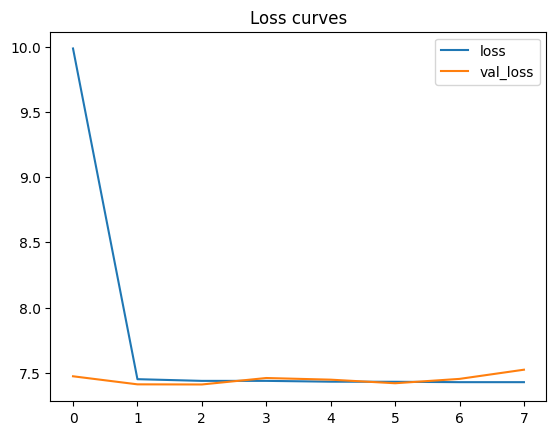

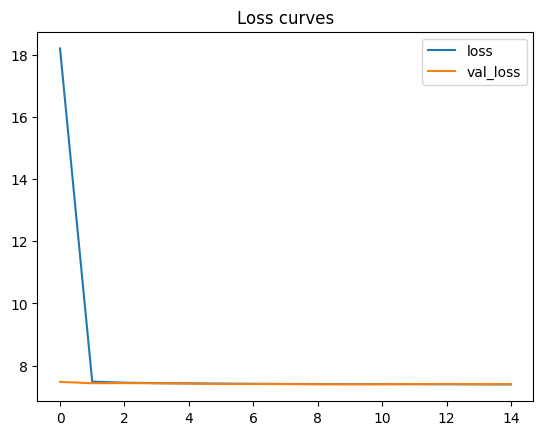

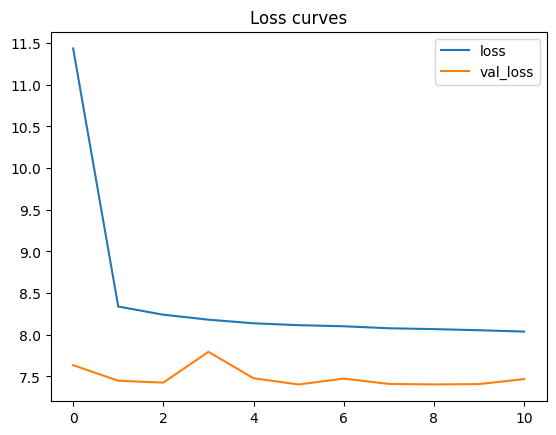

In [78]:
print_history_summary(hist_A)
# graph_loss(hist_A)

print("==========================================")

print_history_summary(hist_B)
# graph_loss(hist_B)

print("==========================================")

print_history_summary(hist_C)
# graph_loss(hist_C)

In [ ]:
# Binary Classification

model_bin_class = keras.Sequential([
    layers.BatchNormalization(input_shape=input_shape),

    layers.Dense(256, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(256, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(1, activation='sigmoid')

])

model_bin_class.compile(
    optimizer="adam",
    loss = 'binary_crossentropy',
    metrics=['binary_accuracy']
)


history_df = pd.DataFrame(history.history)
history_df.loc[:, ['loss', 'val_loss']].plot(title="Cross-entropy")
history_df.loc[:, ['binary_accuracy', 'val_binary_accuracy']].plot(title="Accuracy")

“The cross-validation boxplot shows that both pipelines have very similar MAE distributions. The final pipeline has a slightly lower median and a smaller IQR, which suggests marginally more stable performance across folds. The baseline has one slightly better fold, but the difference is too small to be meaningful.”


## 6. Hyperparameter Tuning

### Cross Validation


- Splits data into k folds (e.g., 5 folds).
- Trains the model k times, each time leaving out one fold.
- Reports the average performance across all folds.

<img src="img/cv.png" width="50%">

Why This is Better

- You get k independent estimates, not just one.
- The average is more stable (lower variance).
- The std dev tells you how consistent the model is across different data splits.


In [ ]:
from sklearn.model_selection import cross_val_score
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def cv_scores(pipeline, X, y, cv=5):
    scores = -1 * cross_val_score(
        pipeline,
        X,
        y,
        cv=cv,
        scoring="neg_mean_absolute_error"
    )
    return scores



baseline_scores = cv_scores(baseline_pipeline, X_train_raw, y_train, cv=5)
final_scores = cv_scores(final_pipeline, X_train_raw, y_train, cv=5)

print("Baseline CV MAE:", baseline_scores.mean(), "+/-", baseline_scores.std())
print("Final CV MAE:", final_scores.mean(), "+/-", final_scores.std())

In [ ]:
score_df = pd.DataFrame({
    "Baseline": baseline_scores,
    "Final": final_scores
})

plt.figure(figsize=(7, 4))
sns.boxplot(data=score_df)
plt.title("Fold-wise MAE distribution")
plt.ylabel("MAE")
plt.xlabel("")
plt.tight_layout()
plt.show()

## 7. Final Model Comparison and Over/Underfitting Analysis

Best parameters found
Why those parameters
Overfitting / underfitting discussion

## 8. Conclusion

Which model you keep
Why it wins overall
What trade-offs it has

## ---

## 9. Advanced AI Lab Topics

- Security: how a student could manipulate inputs
- Bias: sensitive variable check, fairness metric, mitigation
- Explainability: SHAP/LIME-style single prediction explanation

- Security: Some of the data used for failure prediction is provided by the students themselves. Could
a dishonest student lie about certain variables in order to obtain additional tutoring, even if they are
not among the most in need? Try to put yourself in the place of such a student and determine how
one could manipulate the inputs while changing as little information as possible. Is there a risk for the
OCR part?

- Bias: The dataset contains several variables. If sensitive variables are used, how do they affect the
model? Do they introduce unwanted bias? If so, you should evaluate this bias and apply techniques
to mitigate it while trying to maintain the best possible performance.
- Explainability: In the interest of transparency, a school may wish to explain to a student the factors
that made them eligible for special support. We ask you to provide an explanation based on which
and how much input variables influenced the decision. At the same time, and from a more scientific
perspective, a teacher interested in the OCR model would like to know which parts of the image are
used to predict the character. Could you provide such an explanation?



To respond to these aspects you have to submit a 5 page report supplement

Security / manipulation risk
Bias / fairness
Explainability
Keep this as a final applied discussion section

## 10. Conclusion

Main findings
What worked best
Limits of the analysis
Possible next steps